In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


RUN LSTM MODEL

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle


# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape for LSTM input (samples, time steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Convert labels to categorical (31 classes)
num_classes = 31
y = to_categorical(y, num_classes)

# Downsample: Take every second time step
#X = X[:, ::2]  # Select every second column (assuming time steps are along columns)

# Downsample: Take every third time step
#X = X[:, ::3]  # Select every third column (assuming time steps are along columns)

# Reshape for LSTM input (samples, new time steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Split data into training, validation, and test sets 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print dataset sizes
print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Define the LSTM Model
model = Sequential([
    Input(shape=(X.shape[1], 1)),  # Input Shape: 97 time steps, 1 feature per step
    Dropout(0.2),
    LSTM(500), #return_sequences=True),  # Keep return_sequences=True for stacking LSTMs
    Dropout(0.2),
    Dense(31, activation='softmax')  # 31-class classification
])


# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))

# Evaluate on test data
scores = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: %.2f%%" % (scores[1] * 100))

# Plot Training History
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))

Training set: 18594 samples
Validation set: 6198 samples
Test set: 6198 samples


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout_25 (Dropout)                 │ (None, 97, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 500)                 │       1,004,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 31)                  │          15,531 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,019,531 (3.89 MB)

 Trainable params: 1,019,531 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 302s 512ms/step - accuracy: 0.0401 - loss: 3.4312 - val_accuracy: 0.0479 - val_loss: 3.4233
Epoch 2/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 318s 506ms/step - accuracy: 0.0448 - loss: 3.4131 - val_accuracy: 0.0478 - val_loss: 3.3964
Epoch 3/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 322s 505ms/step - accuracy: 0.0460 - loss: 3.3646 - val_accuracy: 0.0318 - val_loss: 3.4326
Epoch 4/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 324s 510ms/step - accuracy: 0.0416 - loss: 3.4207 - val_accuracy: 0.0692 - val_loss: 3.2669
Epoch 5/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 320s 507ms/step - accuracy: 0.0656 - loss: 3.2889 - val_accuracy: 0.0524 - val_loss: 3.3227
Epoch 6/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 295s 506ms/step - accuracy: 0.0756 - loss: 3.2177 - val_accuracy: 0.0529 - val_loss: 3.3836
Epoch 7/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 281s 484ms/step - accuracy: 0.0795 - loss: 3.3173 - val_accuracy: 0.0410 - val_loss: 3.3715
Epoch 8/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 337s 510ms/step - accur

RUN LSTM MODEL (2 lstm layers)

Training set: 18594 samples
Validation set: 6198 samples
Test set: 6198 samples


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout_22 (Dropout)                 │ (None, 97, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_13 (LSTM)                       │ (None, 97, 100)             │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 97, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_14 (LSTM)                       │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 31)                  │           1,581 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 72,581 (283.52 KB)

 Trainable params: 72,581 (283.52 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 50s 82ms/step - accuracy: 0.0480 - loss: 3.3710 - val_accuracy: 0.0579 - val_loss: 3.3033
Epoch 2/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 80s 79ms/step - accuracy: 0.0565 - loss: 3.3426 - val_accuracy: 0.0444 - val_loss: 3.4159
Epoch 3/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 81s 77ms/step - accuracy: 0.0362 - loss: 3.4432 - val_accuracy: 0.0300 - val_loss: 3.4338
Epoch 4/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 81s 76ms/step - accuracy: 0.0376 - loss: 3.4330 - val_accuracy: 0.0313 - val_loss: 3.4371
Epoch 5/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 44s 76ms/step - accuracy: 0.0318 - loss: 3.4355 - val_accuracy: 0.0339 - val_loss: 3.4336
Epoch 6/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 83s 78ms/step - accuracy: 0.0342 - loss: 3.4322 - val_accuracy: 0.0263 - val_loss: 3.4291
Epoch 7/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.0494 - loss: 3.3649 - val_accuracy: 0.0549 - val_loss: 3.3374
Epoch 8/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.0598 - lo

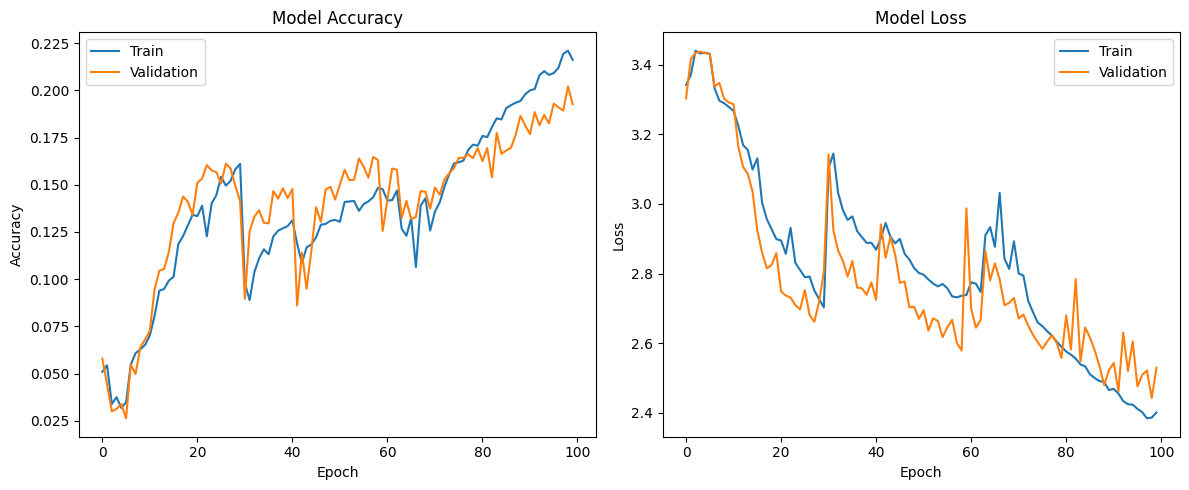

Training history saved successfully!
Reloaded Model Test Accuracy: 18.99%


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle


# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape for LSTM input (samples, time steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Convert labels to categorical (31 classes)
num_classes = 31
y = to_categorical(y, num_classes)

# Downsample: Take every second time step
#X = X[:, ::2]  # Select every second column (assuming time steps are along columns)

# Downsample: Take every third time step
#X = X[:, ::3]  # Select every third column (assuming time steps are along columns)

# Reshape for LSTM input (samples, new time steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Split data into training, validation, and test sets 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print dataset sizes
print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Define the LSTM Model
model = Sequential([
    Input(shape=(X.shape[1], 1)),  # Input Shape: 97 time steps, 1 feature per step
    Dropout(0.2),
    LSTM(100, return_sequences=True),  # Keep return_sequences=True for stacking LSTMs
    Dropout(0.2),
    LSTM(50),  # Added another LSTM layer with 50 units
    Dropout(0.2),
    Dense(31, activation='softmax')  # 31-class classification
])


# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))

# Evaluate on test data
scores = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: %.2f%%" % (scores[1] * 100))

# Plot Training History
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))


#RECREATED LSTM MODEL

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle


# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X_data = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y_data  = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape X for LSTM (assuming 97 features are time steps)
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)

# Convert labels to categorical
num_classes = 31
y_data = to_categorical(y_data, num_classes)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Define model
model = Sequential()
model.add(LSTM(100, input_shape=(X_train.shape[1], 1)))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
print(model.summary())

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

# Evaluate model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1] * 100))

# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 31)                  │           3,131 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,931 (171.61 KB)

 Trainable params: 43,931 (171.61 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 57s 70ms/step - accuracy: 0.0392 - loss: 3.4218 - val_accuracy: 0.0318 - val_loss: 3.4391
Epoch 2/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.0345 - loss: 3.4278 - val_accuracy: 0.0376 - val_loss: 3.4185
Epoch 3/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 80s 68ms/step - accuracy: 0.0476 - loss: 3.3694 - val_accuracy: 0.0353 - val_loss: 3.4228
Epoch 4/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.0490 - loss: 3.3675 - val_accuracy: 0.0323 - val_loss: 3.4334
Epoch 5/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.0407 - loss: 3.4163 - val_accuracy: 0.0978 - val_loss: 3.0746
Epoch 6/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 83s 69ms/step - accuracy: 0.0907 - loss: 3.0652 - val_accuracy: 0.1152 - val_loss: 2.9389
Epoch 7/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.1110 - loss: 2.9522 - val_accuracy: 0.1250 - val_loss: 2.8723
Epoch 8/100
775/775 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.1132 - lo

#RECREATED LSTM 200 EPOCHS

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle


# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X_data = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y_data  = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape X for LSTM (assuming 97 features are time steps)
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)

# Convert labels to categorical
num_classes = 31
y_data = to_categorical(y_data, num_classes)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Define model
model = Sequential()
model.add(LSTM(100, input_shape=(X_train.shape[1], 1)))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
print(model.summary())

# Train model
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test))

# Evaluate model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1] * 100))

# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 31)                  │           3,131 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,931 (171.61 KB)

 Trainable params: 43,931 (171.61 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 56s 69ms/step - accuracy: 0.0467 - loss: 3.3856 - val_accuracy: 0.0540 - val_loss: 3.3061
Epoch 2/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.0454 - loss: 3.3994 - val_accuracy: 0.0549 - val_loss: 3.3119
Epoch 3/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.0533 - loss: 3.3386 - val_accuracy: 0.0924 - val_loss: 3.1705
Epoch 4/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.0623 - loss: 3.3094 - val_accuracy: 0.0673 - val_loss: 3.2994
Epoch 5/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.0795 - loss: 3.1970 - val_accuracy: 0.1225 - val_loss: 3.0046
Epoch 6/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.1149 - loss: 2.9675 - val_accuracy: 0.1281 - val_loss: 2.8959
Epoch 7/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.1231 - loss: 2.9029 - val_accuracy: 0.1352 - val_loss: 2.8399
Epoch 8/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.1196 - lo

#RECREATED LSTM MODEL 2nd time step (downsampled)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle


# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X_data = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y_data  = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape X for LSTM (assuming 97 features are time steps)
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)

# Convert labels to categorical
num_classes = 31
y_data = to_categorical(y_data, num_classes)

# Downsample: Take every second time step
X_data = X_data[:, ::2]  # Select every second column (assuming time steps are along columns)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Define model
model = Sequential()
model.add(LSTM(100, input_shape=(X_train.shape[1], 1)))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
print(model.summary())

# Train model
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test))

# Evaluate model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1] * 100))

# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 31)                  │           3,131 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,931 (171.61 KB)

 Trainable params: 43,931 (171.61 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.0530 - loss: 3.3400 - val_accuracy: 0.0644 - val_loss: 3.2560
Epoch 2/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.0665 - loss: 3.2735 - val_accuracy: 0.0700 - val_loss: 3.2410
Epoch 3/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.0756 - loss: 3.2449 - val_accuracy: 0.1015 - val_loss: 3.0681
Epoch 4/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.1036 - loss: 3.0858 - val_accuracy: 0.1147 - val_loss: 3.0237
Epoch 5/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.1209 - loss: 2.9753 - val_accuracy: 0.1281 - val_loss: 2.9186
Epoch 6/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.1258 - loss: 2.9220 - val_accuracy: 0.1308 - val_loss: 2.8797
Epoch 7/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 44s 45ms/step - accuracy: 0.1284 - loss: 2.8917 - val_accuracy: 0.1373 - val_loss: 2.8461
Epoch 8/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.1358 - lo

#recreated LSTM downsample 3rd time steps

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle


# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X_data = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y_data  = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape X for LSTM (assuming 97 features are time steps)
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)

# Convert labels to categorical
num_classes = 31
y_data = to_categorical(y_data, num_classes)

# Downsample: Take every Third time step
X_data = X_data[:, ::3]  # Select every Third column (assuming time steps are along columns)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Define model
model = Sequential()
model.add(LSTM(100, input_shape=(X_train.shape[1], 1)))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
print(model.summary())

# Train model
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test))

# Evaluate model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1] * 100))

# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 31)                  │           3,131 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,931 (171.61 KB)

 Trainable params: 43,931 (171.61 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.0511 - loss: 3.3371 - val_accuracy: 0.0655 - val_loss: 3.2493
Epoch 2/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.0680 - loss: 3.2643 - val_accuracy: 0.0781 - val_loss: 3.2191
Epoch 3/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.0756 - loss: 3.2373 - val_accuracy: 0.1075 - val_loss: 3.0884
Epoch 4/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.1010 - loss: 3.1005 - val_accuracy: 0.1131 - val_loss: 3.0269
Epoch 5/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.1140 - loss: 3.0216 - val_accuracy: 0.1241 - val_loss: 2.9750
Epoch 6/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.1197 - loss: 2.9908 - val_accuracy: 0.1307 - val_loss: 2.9467
Epoch 7/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.1257 - loss: 2.9706 - val_accuracy: 0.1326 - val_loss: 2.9254
Epoch 8/200
775/775 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.1268 - lo

#recreate lstm model with val split with addition of epoch 80 checkpoint

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle

# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X_data = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y_data = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape X for LSTM (assuming 97 features are time steps)
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)

# Convert labels to categorical
num_classes = 31
y_data = to_categorical(y_data, num_classes)

# Split data into training, validation, and test sets 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define model
model = Sequential()
model.add(LSTM(100, input_shape=(X_train.shape[1], 1)))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
print(model.summary())

# Define checkpoint to save at every epoch
checkpoint_path = os.path.join(drive_path, "lstm_epoch80.weights.h5") # Changed extension to .weights.h5
history_path = os.path.join(drive_path, "lstm_epoch80_history.pkl")

# ... (rest of the code remains the same) ...
checkpoint_callback = ModelCheckpoint(filepath=checkpoint_path,
                                       save_best_only=False,
                                       save_weights_only=True,
                                       save_freq='epoch',
                                       verbose=1)

history = model.fit(X_train, y_train,
                    epochs=200,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    callbacks=[checkpoint_callback])

# Extract weights and performance at epoch 80
epoch_80_weights_path = os.path.join(drive_path, "lstm_epoch80_weights.keras")
epoch_80_model_path = os.path.join(drive_path, "lstm_epoch80_model.keras")

if len(history.history['accuracy']) >= 80:
    # Load weights from epoch 80 checkpoint
    model.load_weights(checkpoint_path)

    # Save the full model at epoch 80
    model.save(epoch_80_model_path)

    # Save only weights at epoch 80
    model.save_weights(epoch_80_weights_path)
    print("Model and weights at epoch 80 saved successfully.")

# Evaluate the saved model for epoch 80
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
scores = model.evaluate(X_test, y_test, verbose=0)
print("Epoch 80 Model Test Accuracy: %.2f%%" % (scores[1] * 100))

# Save training history for future reference
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")


# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 31)                  │           3,131 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,931 (171.61 KB)

 Trainable params: 43,931 (171.61 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0375 - loss: 3.4211
Epoch 1: saving model to /content/drive/MyDrive/Colab Notebooks/LSTM RUNS/lstm_epoch80.weights.h5
582/582 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.0375 - loss: 3.4210 - val_accuracy: 0.0623 - val_loss: 3.2974
Epoch 2/200
581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0567 - loss: 3.3521
Epoch 2: saving model to /content/drive/MyDrive/Colab Notebooks/LSTM RUNS/lstm_epoch80.weights.h5
582/582 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.0567 - loss: 3.3522 - val_accuracy: 0.0300 - val_loss: 3.4415
Epoch 3/200
581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0476 - loss: 3.3749
Epoch 3: saving model to /content/drive/MyDrive/Colab Notebooks/LSTM RUNS/lstm_epoch80.weights.h5
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - accuracy: 0.0477 - loss: 3.3747 - val_accuracy: 0.0628 - val_loss: 3.3149
Epoch 4/200
581/582 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0576 - loss:

#RECREATED LSTM MODEL WITH VALIDATION SPLIT

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 31)                  │           3,131 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,931 (171.61 KB)

 Trainable params: 43,931 (171.61 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/80
582/582 ━━━━━━━━━━━━━━━━━━━━ 63s 95ms/step - accuracy: 0.0413 - loss: 3.3912 - val_accuracy: 0.0592 - val_loss: 3.3469
Epoch 2/80
582/582 ━━━━━━━━━━━━━━━━━━━━ 45s 78ms/step - accuracy: 0.0556 - loss: 3.3380 - val_accuracy: 0.0382 - val_loss: 3.4230
Epoch 3/80
582/582 ━━━━━━━━━━━━━━━━━━━━ 85s 84ms/step - accuracy: 0.0407 - loss: 3.4056 - val_accuracy: 0.0426 - val_loss: 3.4069
Epoch 4/80
582/582 ━━━━━━━━━━━━━━━━━━━━ 79s 79ms/step - accuracy: 0.0427 - loss: 3.3946 - val_accuracy: 0.0305 - val_loss: 3.4358
Epoch 5/80
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.0354 - loss: 3.4329 - val_accuracy: 0.0368 - val_loss: 3.4275
Epoch 6/80
582/582 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.0420 - loss: 3.4171 - val_accuracy: 0.0647 - val_loss: 3.2957
Epoch 7/80
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.0483 - loss: 3.3589 - val_accuracy: 0.0350 - val_loss: 3.4774
Epoch 8/80
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 79ms/step - accuracy: 0.0515 - loss: 3.35

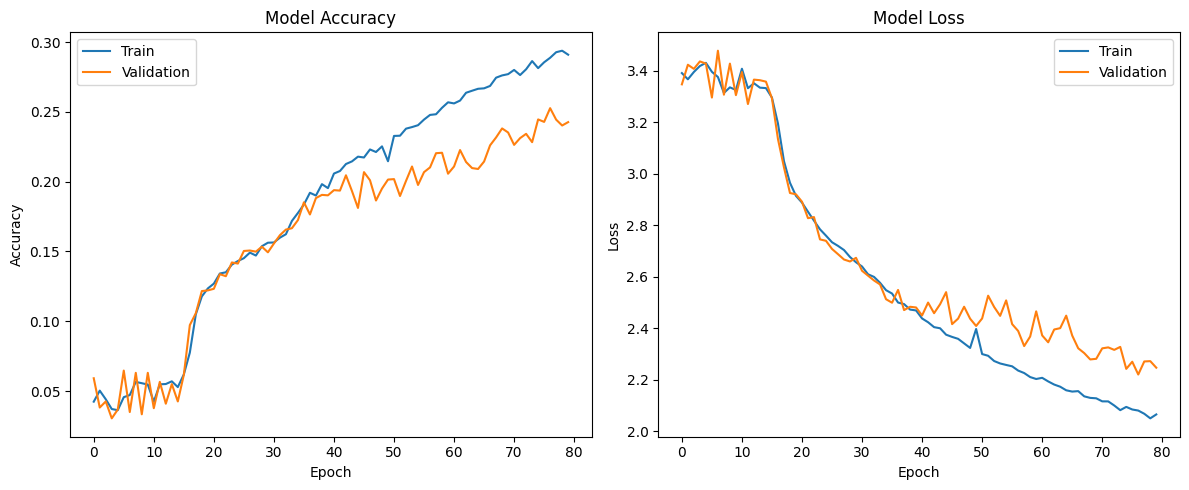

Training history saved successfully!
Reloaded Model Test Accuracy: 23.81%


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle


# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X_data = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y_data  = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape X for LSTM (assuming 97 features are time steps)
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)

# Convert labels to categorical
num_classes = 31
y_data = to_categorical(y_data, num_classes)

# Split data into training, validation, and test sets 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define model
model = Sequential()
model.add(LSTM(100, input_shape=(X_train.shape[1], 1)))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
print(model.summary())

# Train model
history = model.fit(X_train, y_train, epochs=80, batch_size=32, validation_data=(X_val, y_val))

# Evaluate model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1] * 100))

# Plot Training History
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))

#VALIDATION SPLIT WITH DOWNSAMPLE 2ND TIME STEP

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 31)                  │           3,131 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,931 (171.61 KB)

 Trainable params: 43,931 (171.61 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.0469 - loss: 3.3829 - val_accuracy: 0.0434 - val_loss: 3.4068
Epoch 2/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.0334 - loss: 3.4453 - val_accuracy: 0.0305 - val_loss: 3.4354
Epoch 3/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - accuracy: 0.0337 - loss: 3.4345 - val_accuracy: 0.0300 - val_loss: 3.4365
Epoch 4/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.0359 - loss: 3.4326 - val_accuracy: 0.0408 - val_loss: 3.4179
Epoch 5/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.0421 - loss: 3.4165 - val_accuracy: 0.0360 - val_loss: 3.4279
Epoch 6/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.0386 - loss: 3.4274 - val_accuracy: 0.0300 - val_loss: 3.4375
Epoch 7/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.0356 - loss: 3.4351 - val_accuracy: 0.0392 - val_loss: 3.4169
Epoch 8/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.0496 - lo

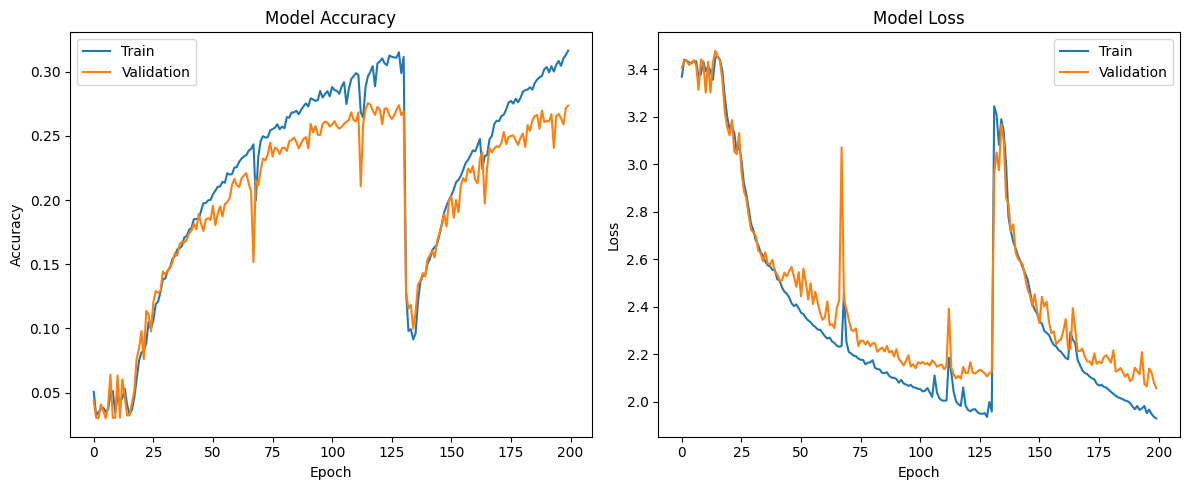

Training history saved successfully!
Reloaded Model Test Accuracy: 26.69%


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle


# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X_data = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y_data  = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape X for LSTM (assuming 97 features are time steps)
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)

# Convert labels to categorical
num_classes = 31
y_data = to_categorical(y_data, num_classes)

# Downsample: Take every second time step
X_data = X_data[:, ::2]  # Select every second column (assuming time steps are along columns)

# Split data into training, validation, and test sets 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define model
model = Sequential()
model.add(LSTM(100, input_shape=(X_train.shape[1], 1)))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
print(model.summary())

# Train model
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_val, y_val))

# Evaluate model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1] * 100))

# Plot Training History
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))

#recreated lstm model 3rd time steps

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 31)                  │           3,131 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,931 (171.61 KB)

 Trainable params: 43,931 (171.61 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 70ms/step - accuracy: 0.0470 - loss: 3.3884 - val_accuracy: 0.0342 - val_loss: 3.4073
Epoch 2/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.0536 - loss: 3.3719 - val_accuracy: 0.0582 - val_loss: 3.3038
Epoch 3/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.0623 - loss: 3.2949 - val_accuracy: 0.0452 - val_loss: 3.3923
Epoch 4/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 39s 67ms/step - accuracy: 0.0458 - loss: 3.3632 - val_accuracy: 0.0660 - val_loss: 3.2768
Epoch 5/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.0563 - loss: 3.3337 - val_accuracy: 0.0681 - val_loss: 3.2834
Epoch 6/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.0445 - loss: 3.3919 - val_accuracy: 0.0344 - val_loss: 3.4161
Epoch 7/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 65ms/step - accuracy: 0.0414 - loss: 3.4054 - val_accuracy: 0.0344 - val_loss: 3.4455
Epoch 8/200
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.0524 - lo

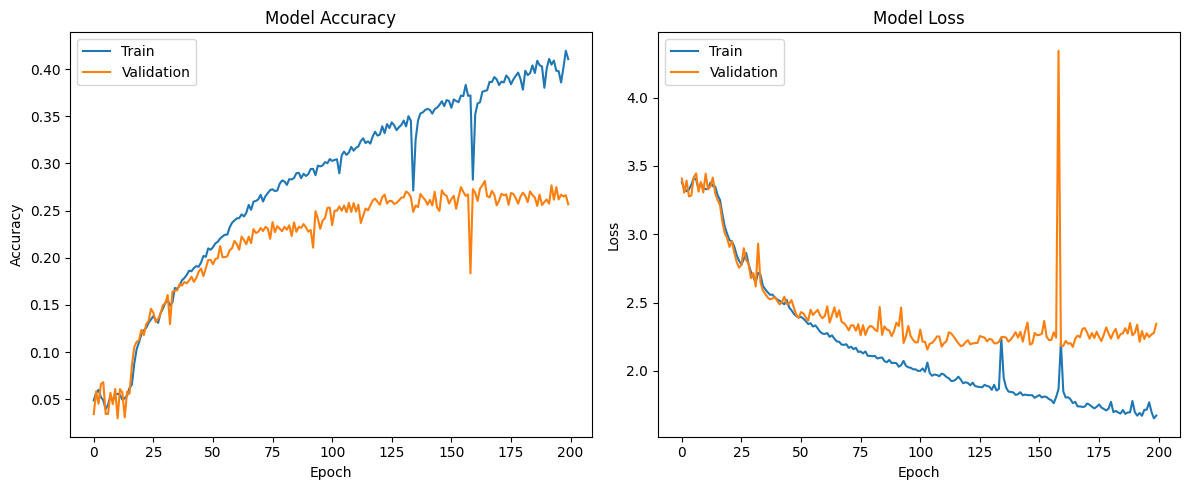

Training history saved successfully!
Reloaded Model Test Accuracy: 25.86%


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import pickle


# Define Google Drive Save Path
drive_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS"

# Set seed for reproducibility
tf.random.set_seed(5)

# Load datasets
X_data = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_X_traj_.csv', header=None).values
y_data  = pd.read_csv('/content/drive/My Drive/Comb_ligands_31conditions_y_traj_.csv', header=None).values.flatten()

# Reshape X for LSTM (assuming 97 features are time steps)
X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)

# Convert labels to categorical
num_classes = 31
y_data = to_categorical(y_data, num_classes)

# Downsample: Take every third time step
X_data = X_data[:, ::3]  # Select every third column (assuming time steps are along columns)

# Split data into training, validation, and test sets 60/20/20 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define model
model = Sequential()
model.add(LSTM(100, input_shape=(X_train.shape[1], 1)))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
print(model.summary())

# Train model
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_val, y_val))

# Evaluate model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1] * 100))

# Plot Training History
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Save the trained model
model.save(os.path.join(drive_path, "lstm_model.keras"))

# Load the saved model
model = load_model(os.path.join(drive_path, "lstm_model.keras"))

# Recompile the model to restore metrics
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history.pkl"

# Save training history before closing the session
with open(history_path, 'wb') as file:
    pickle.dump(history.history, file)

print("Training history saved successfully!")

# Evaluate the reloaded model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Reloaded Model Test Accuracy: %.2f%%" % (scores[1] * 100))

**LOAD SAVED LSTM MODELS**

Training history loaded successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 31)                  │           3,131 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 131,795 (514.83 KB)

 Trainable params: 43,931 (171.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 87,864 (343.22 KB)

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Training Accuracy per epoch:
[0.05012369528412819, 0.03802301734685898, 0.03431214392185211, 0.03985156491398811, 0.07163601368665695, 0.097773477435112, 0.1121867299079895, 0.11761858314275742, 0.12025384604930878, 0.12724535167217255, 0.10347423702478409, 0.10083898156881332, 0.10680864751338959, 0.1156286969780922, 0.12294288724660873, 0.12966547906398773, 0.13299989700317383, 0.13923846185207367, 0.1411745697259903, 0.14413250982761383, 0.14402495324611664, 0.11616650223731995, 0.13267721235752106, 0.13687211275100708, 0.1400989592075348, 0.1398838311433792, 0.14461654424667358, 0.11837151646614075, 0.13735613226890564, 0.14515435695648193, 0.15166182816028595, 0.15241475403308868, 0.1555878221988678, 0.1545122116804123, 0.15617941319942474, 0.16032053530216217, 0.15763148665428162, 0.15687856078147888, 0.15983650088310242, 0.1644616574048996, 0.16645154356956482, 0.1689254641532898, 0.16698935627937317, 0.1751640290021896

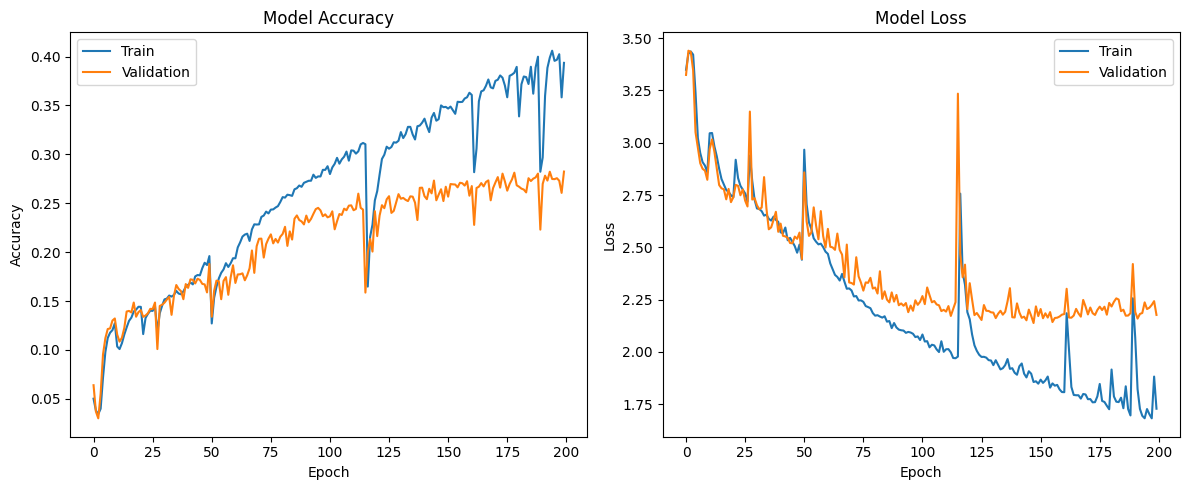

In [ ]:
from tensorflow.keras.models import load_model
import pickle
import matplotlib.pyplot as plt

history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/valtestrecreate.pkl"

# Load history object
with open(history_path, 'rb') as file:
    loaded_history = pickle.load(file)

print("Training history loaded successfully!")

model_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/valtestrecreate.keras"
model = load_model(model_path)


# Check model summary
model.summary()

# Print all keys in the loaded_history
print(loaded_history.keys()) # Changed 'history' to 'loaded_history'

# Print all epoch values for accuracy
print("Training Accuracy per epoch:")
print(loaded_history['accuracy']) # Changed 'history' to 'loaded_history'

print("\nValidation Accuracy per epoch:")
print(loaded_history['val_accuracy']) # Changed 'history' to 'loaded_history'

print("\nTraining Loss per epoch:")
print(loaded_history['loss']) # Changed 'history' to 'loaded_history'

print("\nValidation Loss per epoch:")
print(loaded_history['val_loss']) # Changed 'history' to 'loaded_history'

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(loaded_history['accuracy'], label='Train') # Changed 'history' to 'loaded_history'
plt.plot(loaded_history['val_accuracy'], label='Validation') # Changed 'history' to 'loaded_history'
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(loaded_history['loss'], label='Train') # Changed 'history' to 'loaded_history'
plt.plot(loaded_history['val_loss'], label='Validation') # Changed 'history' to 'loaded_history'
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

#Visualize LSTM

**Heatmap of sensitivity & precision (X_temp, y_temp) using model at specific epochs if needed**

In [1]:
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.models import load_model
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define label mapping
label_mapping = {i: name for i, name in enumerate([
    'TNF', 'LPS', 'CpG', 'PolyIC', 'Pam3CSK',
    'TNF_LPS', 'TNF_CpG', 'TNF_PolyIC', 'TNF_Pam3CSK',
    'LPS_CpG', 'LPS_PolyIC', 'LPS_Pam3CSK', 'CpG_PolyIC',
    'CpG_Pam3CSK', 'PolyIC_Pam3CSK', 'TNF_LPS_CpG',
    'TNF_LPS_PolyIC', 'TNF_LPS_Pam3CSK', 'TNF_CpG_PolyIC',
    'TNF_CpG_Pam3CSK', 'TNF_PolyIC_Pam3CSK', 'LPS_CpG_PolyIC',
    'LPS_CpG_Pam3CSK', 'LPS_PolyIC_Pam3CSK', 'CpG_PolyIC_Pam3CSK',
    'TNF_LPS_CpG_PolyIC', 'TNF_LPS_CpG_Pam3CSK',
    'TNF_LPS_PolyIC_Pam3CSK', 'TNF_CpG_PolyIC_Pam3CSK',
    'LPS_CpG_PolyIC_Pam3CSK', 'TNF_LPS_CpG_PolyIC_Pam3CSK'
])}

# Load training history
history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/valtestrecreatepoch80.pkl"
with open(history_path, 'rb') as file:
    loaded_history = pickle.load(file)
print("Training history loaded successfully!")

# Load the trained LSTM model
model_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/valtestrecreatepoch80.keras"
model = load_model(model_path)
print("Model loaded successfully!")

# Load dataset
X_data_path = "/content/drive/MyDrive/Comb_ligands_31conditions_X_traj_.csv"
y_data_path = "/content/drive/MyDrive/Comb_ligands_31conditions_y_traj_.csv"

X = pd.read_csv(X_data_path, header=None).values.reshape((-1, 97, 1))
y = pd.read_csv(y_data_path, header=None).values.flatten()

# Convert labels to categorical (31 classes)
num_classes = 31
y = to_categorical(y, num_classes)

# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Get model predictions
y_pred = model.predict(X_temp)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_temp, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print(f"Sum of confusion matrix: {np.sum(cm)}")

# Compute recall (sensitivity)
TP = np.diag(cm)
FN = np.sum(cm, axis=1) - TP
recall = TP / (TP + FN + 1e-10)  # Prevent division by zero
recall_matrix = np.nan_to_num(cm / np.sum(cm, axis=1, keepdims=True))
recall_diag_matrix = np.zeros_like(recall_matrix)
np.fill_diagonal(recall_diag_matrix, np.diag(recall_matrix))

# Compute precision
FP = np.sum(cm, axis=0) - TP
precision = TP / (TP + FP + 1e-10)  # Prevent division by zero
precision_matrix = np.nan_to_num(cm / np.sum(cm, axis=0, keepdims=True))
precision_diag_matrix = np.zeros_like(precision_matrix)
np.fill_diagonal(precision_diag_matrix, np.diag(precision_matrix))

# Compute F1-score using only diagonal values
f1_score_diag = 2 * (np.diag(precision_diag_matrix) * np.diag(recall_diag_matrix)) / \
                (np.diag(precision_diag_matrix) + np.diag(recall_diag_matrix) + 1e-10)

# Create a diagonal matrix for F1-score
f1_diag_matrix = np.zeros((num_classes, num_classes))
np.fill_diagonal(f1_diag_matrix, f1_score_diag)

# Convert label indices to class names
labels = [label_mapping[i] for i in range(num_classes)]

# Plot Sensitivity (Recall) Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(recall_matrix, annot=True, fmt='.3f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Sensitivity (Recall) Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Plot Precision Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(precision_matrix, annot=True, fmt='.3f', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.title('Precision Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Mask off-diagonal elements for F1-score heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(f1_diag_matrix, annot=True, fmt='.3f', cmap='coolwarm', xticklabels=labels, yticklabels=labels,
            mask=(f1_diag_matrix == 0))  # Mask zeros instead of setting NaNs explicitly
plt.title('F1-score Heatmap (True positives only)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Ensure recall and precision arrays match the label mapping order
ordered_indices = list(label_mapping.keys())  # Get indices in correct order
ordered_labels = [label_mapping[i] for i in ordered_indices]
ordered_recall = [recall[i] for i in ordered_indices]
ordered_precision = [precision[i] for i in ordered_indices]
ordered_f1score = np.diag(f1_diag_matrix)  # Extract diagonal (true positive F1-scores)

# Plot Sensitivity (Recall) Bar Plot
plt.figure(figsize=(20, 8))
colors = sns.color_palette("Blues_r", n_colors=len(label_mapping))
sns.barplot(x=ordered_labels, y=ordered_recall, palette=colors)
plt.title("True Positive Predictions using Recall (Sensitivity)")
plt.xlabel("Predicted Ligand")
plt.ylabel("True Positives")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.show()

# Plot Precision Bar Plot
plt.figure(figsize=(20, 8))
colors_p = sns.color_palette("Reds_r", n_colors=len(label_mapping))
sns.barplot(x=ordered_labels, y=ordered_precision, palette=colors_p)
plt.title("True Positive Predictions using Precision")
plt.xlabel("Predicted Ligand")
plt.ylabel("True Positives")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.show()

# Plot F1 Score Bar Plot
plt.figure(figsize=(20, 8))
colors_f = sns.color_palette("coolwarm_r", n_colors=len(label_mapping))
sns.barplot(x=ordered_labels, y=ordered_f1score, palette=colors_f)
plt.title("True Positive Predictions using F1 Score ")
plt.xlabel("Predicted Ligand")
plt.ylabel("True Positives")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.show()




FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/valtestrecreatepoch80.pkl'

ownsampled 2nd, epoch 35 (optimal)

Training history loaded successfully!
Model loaded successfully!
Epoch 35 - Loss: 2.707092046737671, Accuracy: 0.16585995256900787
388/388 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step
Sum of confusion matrix: 12396


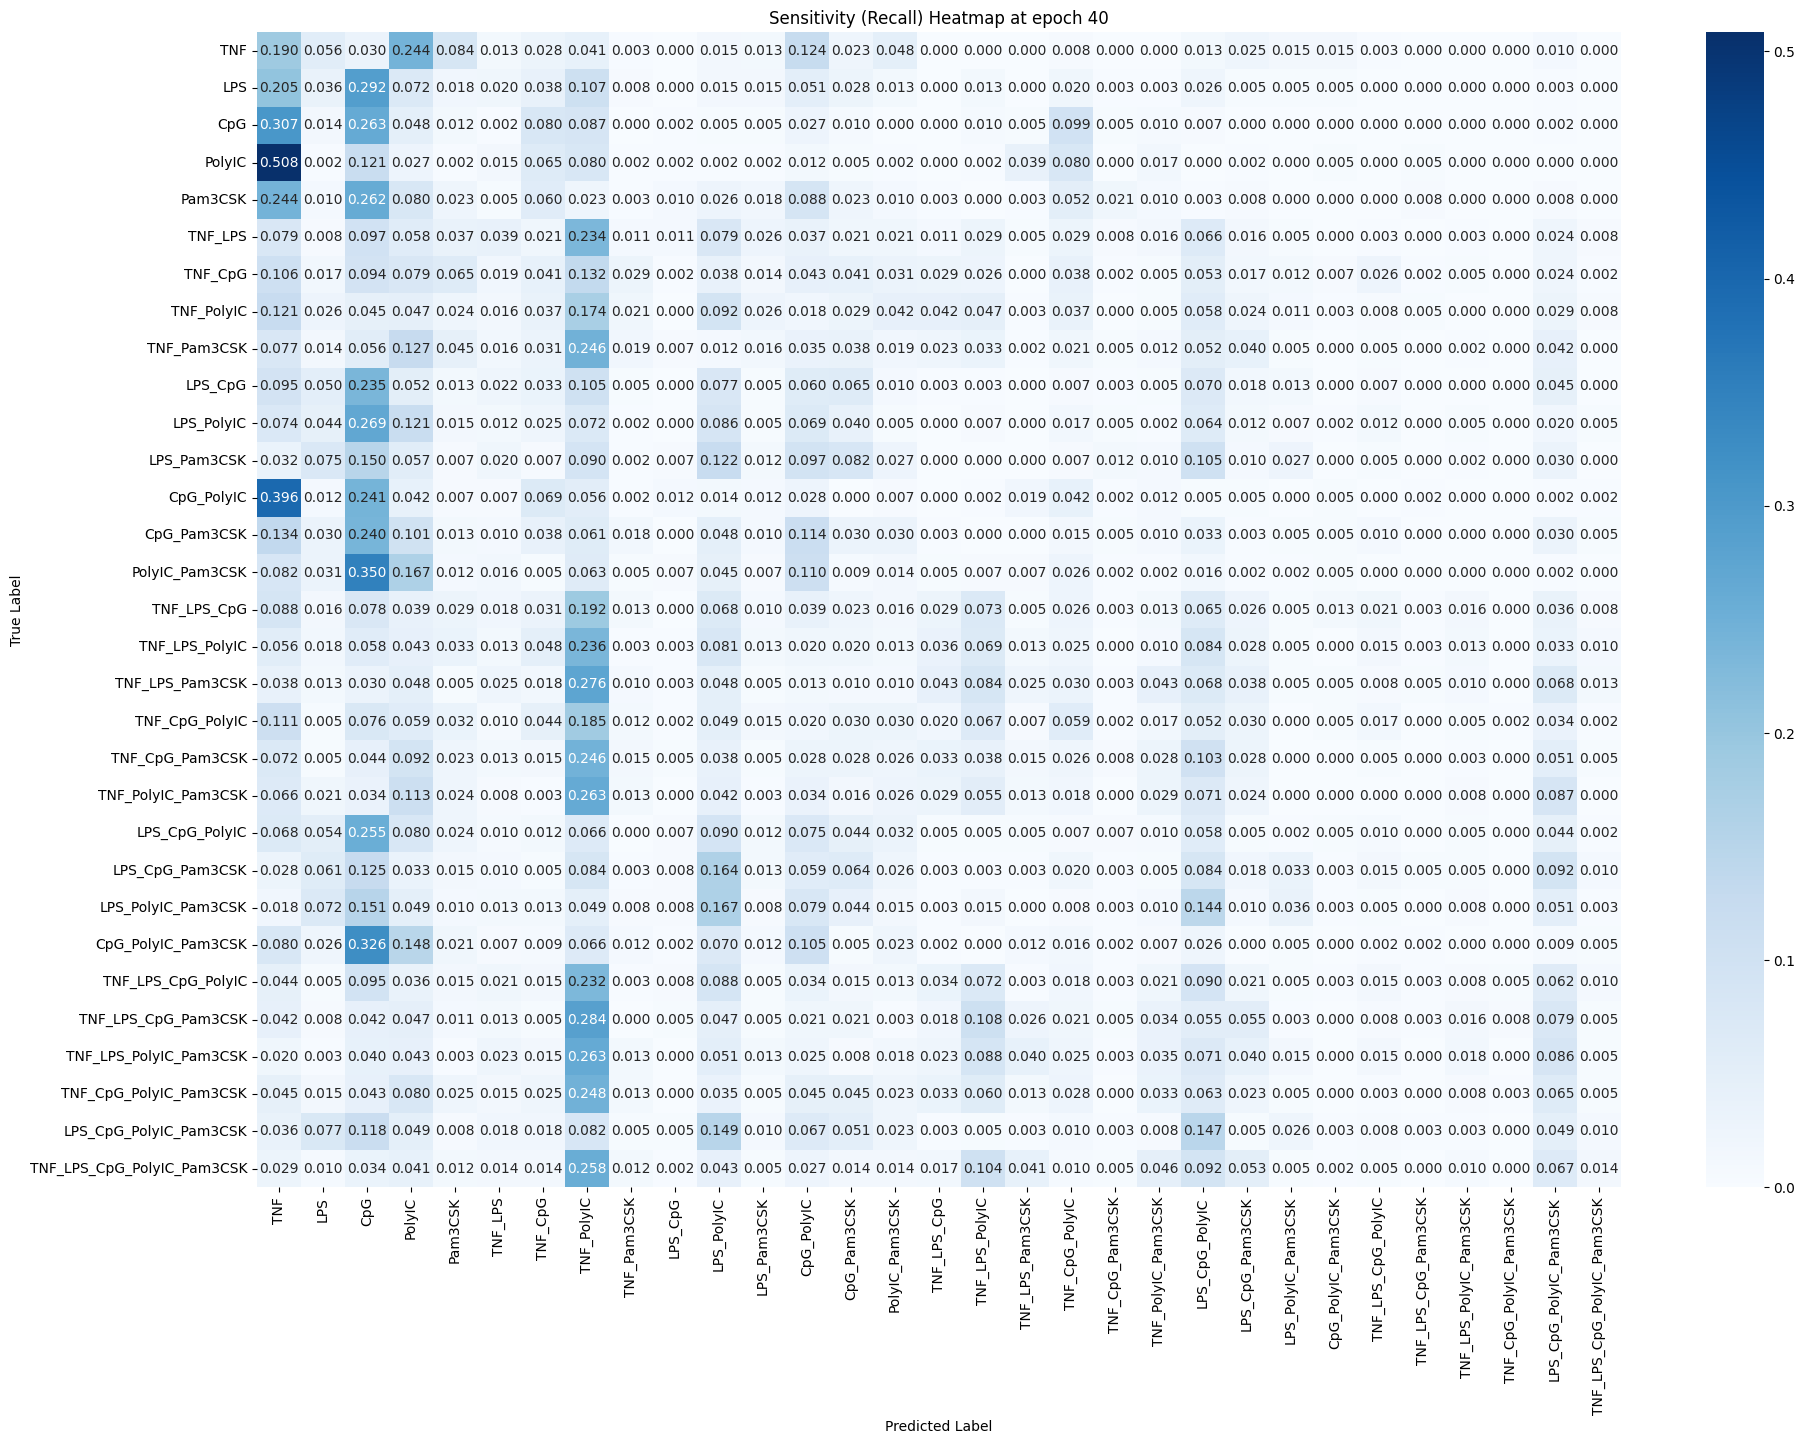

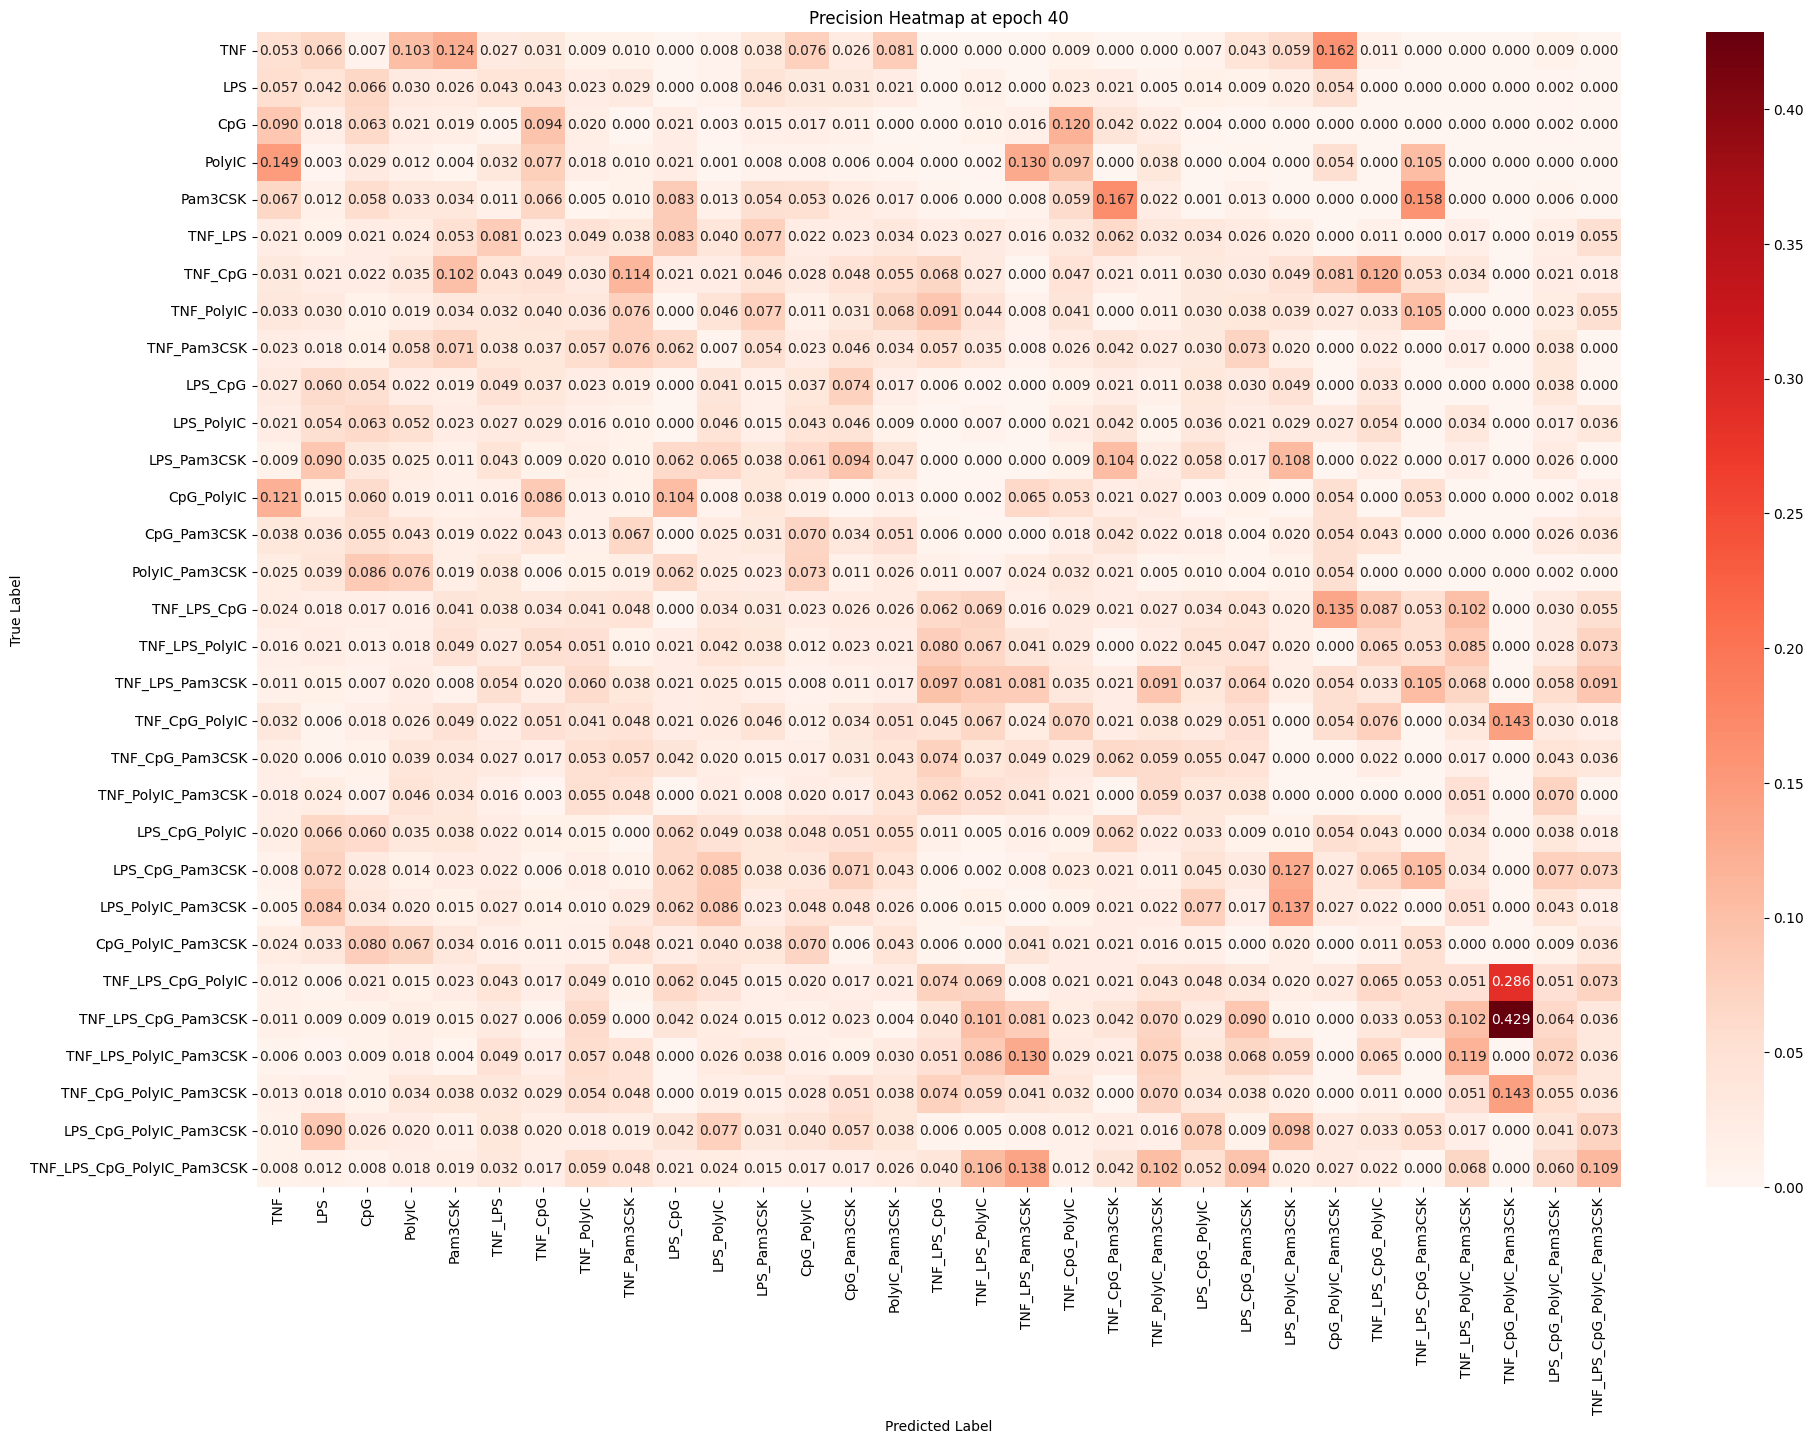

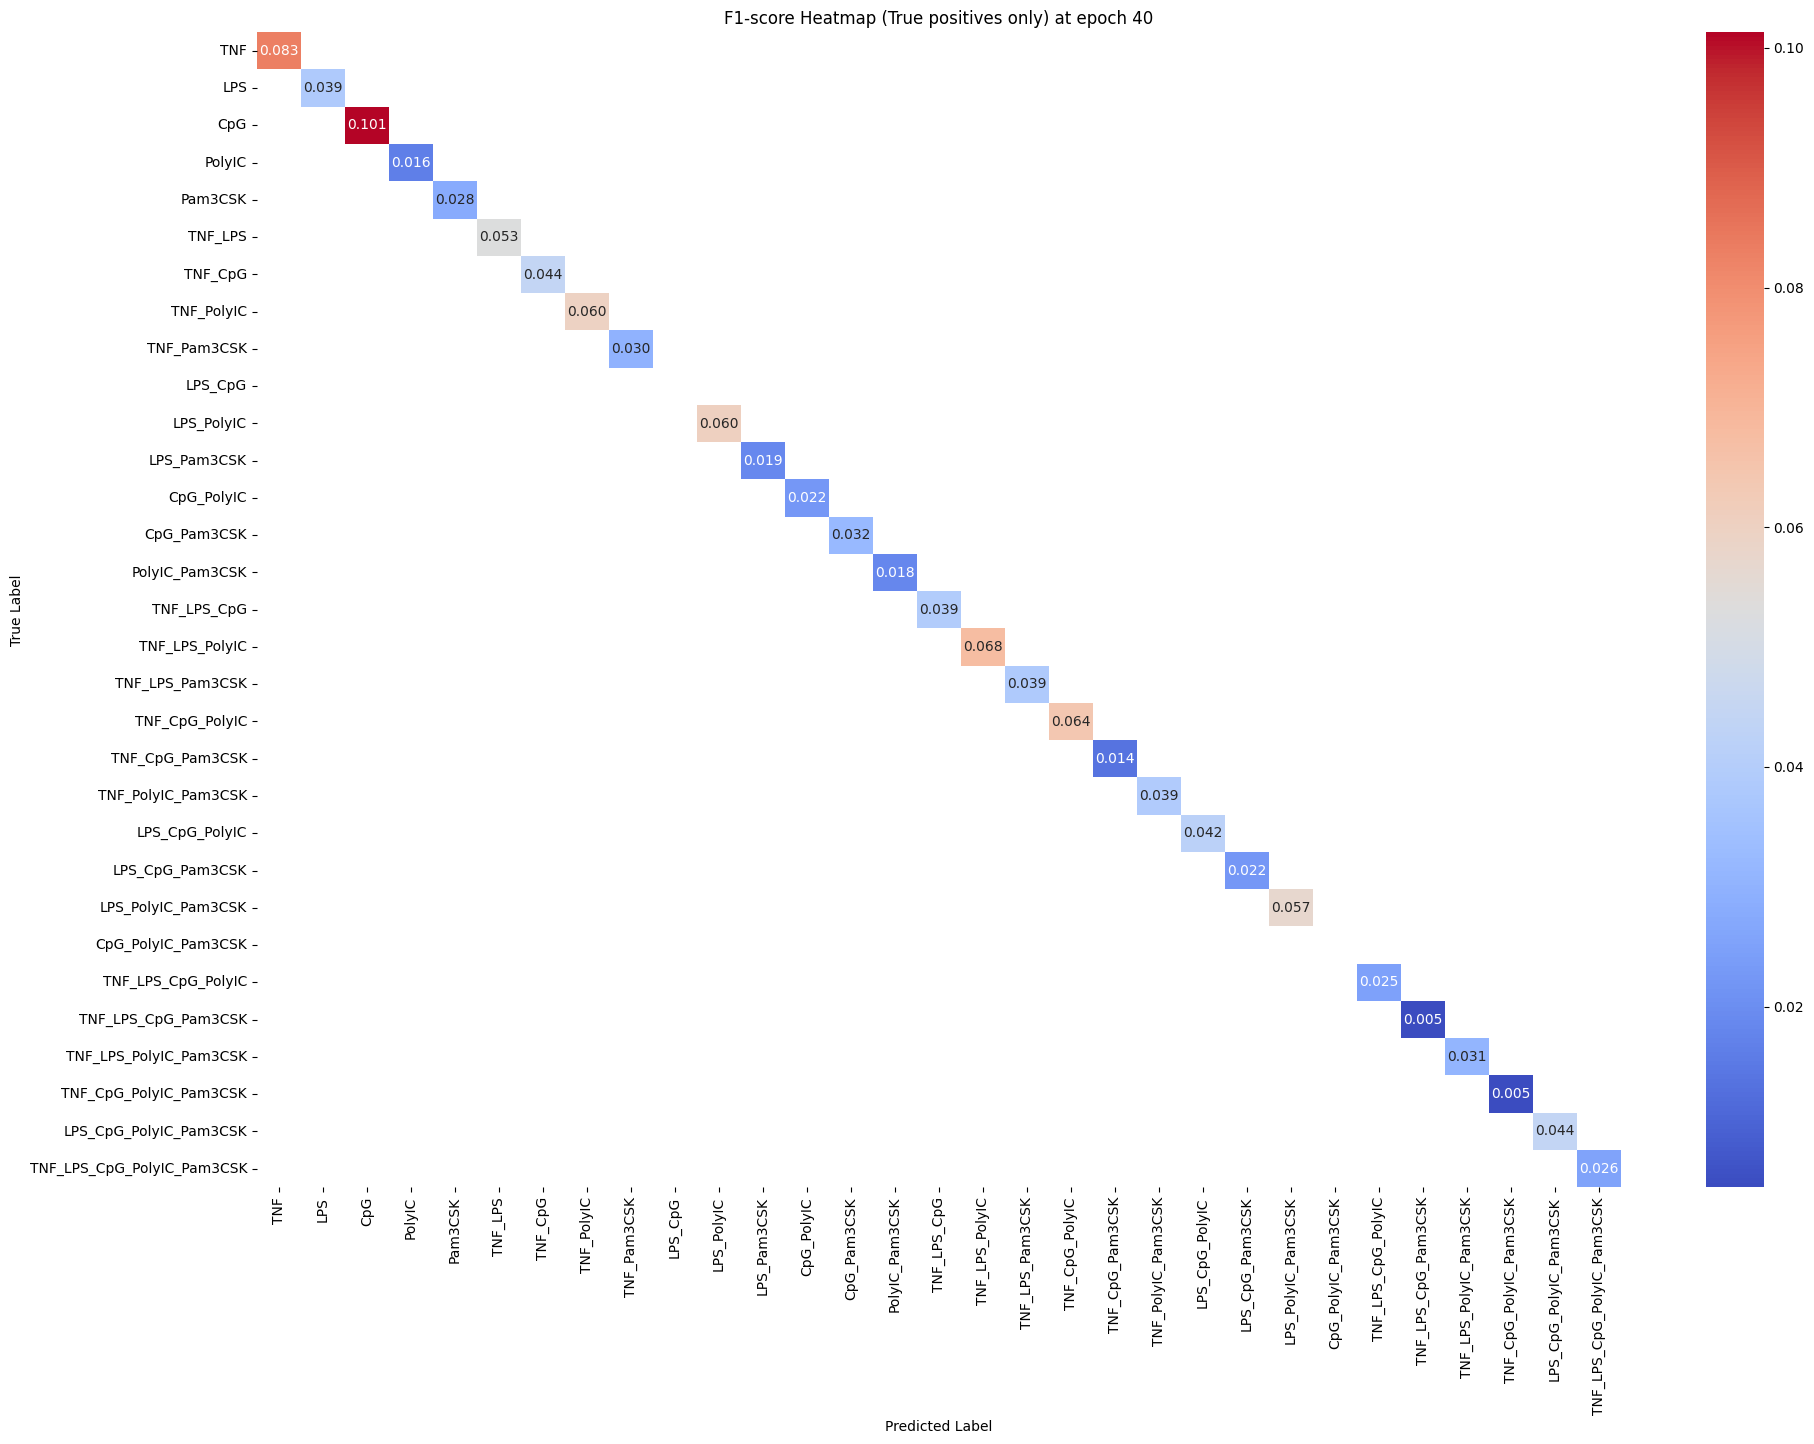

In [ ]:
# Extract Specific Epochs
#if 75 < len(loaded_history['loss']):
    #print(f"Epoch 75 - Loss: {loaded_history['loss'][74]}, Accuracy: {loaded_history['accuracy'][74]}")
#else:
    #print("Epoch 75 is out of range.")

import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.models import load_model
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define label mapping
label_mapping = {i: name for i, name in enumerate([
    'TNF', 'LPS', 'CpG', 'PolyIC', 'Pam3CSK',
    'TNF_LPS', 'TNF_CpG', 'TNF_PolyIC', 'TNF_Pam3CSK',
    'LPS_CpG', 'LPS_PolyIC', 'LPS_Pam3CSK', 'CpG_PolyIC',
    'CpG_Pam3CSK', 'PolyIC_Pam3CSK', 'TNF_LPS_CpG',
    'TNF_LPS_PolyIC', 'TNF_LPS_Pam3CSK', 'TNF_CpG_PolyIC',
    'TNF_CpG_Pam3CSK', 'TNF_PolyIC_Pam3CSK', 'LPS_CpG_PolyIC',
    'LPS_CpG_Pam3CSK', 'LPS_PolyIC_Pam3CSK', 'CpG_PolyIC_Pam3CSK',
    'TNF_LPS_CpG_PolyIC', 'TNF_LPS_CpG_Pam3CSK',
    'TNF_LPS_PolyIC_Pam3CSK', 'TNF_CpG_PolyIC_Pam3CSK',
    'LPS_CpG_PolyIC_Pam3CSK', 'TNF_LPS_CpG_PolyIC_Pam3CSK'
])}

# Load downsampled training history
history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history(downsample2nd).pkl"
with open(history_path, 'rb') as file:
    loaded_history = pickle.load(file)
print("Training history loaded successfully!")

# Load downsampled model
model_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/lstm_model(downsample2nd).keras"
model = load_model(model_path)
print("Model loaded successfully!")

# Extract epoch 35 if it exists
if 35 < len(loaded_history['loss']):
    print(f"Epoch 35 - Loss: {loaded_history['loss'][34]}, Accuracy: {loaded_history['accuracy'][34]}")
else:
    print("Epoch 35 is out of range.")

# Load dataset
X_data_path = "/content/drive/MyDrive/Comb_ligands_31conditions_X_traj_.csv"
y_data_path = "/content/drive/MyDrive/Comb_ligands_31conditions_y_traj_.csv"

X = pd.read_csv(X_data_path, header=None).values.reshape((-1, 97, 1))
y = pd.read_csv(y_data_path, header=None).values.flatten()

# Convert labels to categorical (31 classes)
num_classes = 31
y = to_categorical(y, num_classes)

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Get model predictions
y_pred = model.predict(X_temp)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_temp, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print(f"Sum of confusion matrix: {np.sum(cm)}")

# Compute recall (sensitivity)
TP = np.diag(cm)
FN = np.sum(cm, axis=1) - TP
recall = TP / (TP + FN + 1e-10)
recall_matrix = np.nan_to_num(cm / np.sum(cm, axis=1, keepdims=True))

# Compute precision
FP = np.sum(cm, axis=0) - TP
precision = TP / (TP + FP + 1e-10)
precision_matrix = np.nan_to_num(cm / np.sum(cm, axis=0, keepdims=True))

# Compute F1-score
denom = (np.diag(precision_matrix) + np.diag(recall_matrix) + 1e-10)
f1_score_diag = 2 * (np.diag(precision_matrix) * np.diag(recall_matrix)) / denom
f1_diag_matrix = np.zeros((num_classes, num_classes))
np.fill_diagonal(f1_diag_matrix, f1_score_diag)

# Labels for plotting
labels = [label_mapping[i] for i in range(num_classes)]

# Plot Sensitivity (Recall) Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(recall_matrix, annot=True, fmt='.3f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Sensitivity (Recall) Heatmap at epoch 40')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Plot Precision Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(precision_matrix, annot=True, fmt='.3f', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.title('Precision Heatmap at epoch 40')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Plot F1 Score Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(f1_diag_matrix, annot=True, fmt='.3f', cmap='coolwarm', xticklabels=labels, yticklabels=labels,
            mask=(f1_diag_matrix == 0))
plt.title('F1-score Heatmap (True positives only) at epoch 40')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


In [ ]:
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.models import load_model
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define label mapping
label_mapping = {i: name for i, name in enumerate([
    'TNF', 'LPS', 'CpG', 'PolyIC', 'Pam3CSK',
    'TNF_LPS', 'TNF_CpG', 'TNF_PolyIC', 'TNF_Pam3CSK',
    'LPS_CpG', 'LPS_PolyIC', 'LPS_Pam3CSK', 'CpG_PolyIC',
    'CpG_Pam3CSK', 'PolyIC_Pam3CSK', 'TNF_LPS_CpG',
    'TNF_LPS_PolyIC', 'TNF_LPS_Pam3CSK', 'TNF_CpG_PolyIC',
    'TNF_CpG_Pam3CSK', 'TNF_PolyIC_Pam3CSK', 'LPS_CpG_PolyIC',
    'LPS_CpG_Pam3CSK', 'LPS_PolyIC_Pam3CSK', 'CpG_PolyIC_Pam3CSK',
    'TNF_LPS_CpG_PolyIC', 'TNF_LPS_CpG_Pam3CSK',
    'TNF_LPS_PolyIC_Pam3CSK', 'TNF_CpG_PolyIC_Pam3CSK',
    'LPS_CpG_PolyIC_Pam3CSK', 'TNF_LPS_CpG_PolyIC_Pam3CSK'
])}

# Load downsampled training history
history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history(downsample3rd).pkl"
with open(history_path, 'rb') as file:
    loaded_history = pickle.load(file)
print("Training history loaded successfully!")

# Load downsampled model
model_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/lstm_model(downsample3rd).keras"
model = load_model(model_path)
print("Model loaded successfully!")

# Extract epoch 35 if it exists
if 35 < len(loaded_history['loss']):
    print(f"Epoch 35 - Loss: {loaded_history['loss'][34]}, Accuracy: {loaded_history['accuracy'][34]}")
else:
    print("Epoch 35 is out of range.")

# Load dataset
X_data_path = "/content/drive/MyDrive/Comb_ligands_31conditions_X_traj_.csv"
y_data_path = "/content/drive/MyDrive/Comb_ligands_31conditions_y_traj_.csv"

X = pd.read_csv(X_data_path, header=None).values.reshape((-1, 97, 1))
y = pd.read_csv(y_data_path, header=None).values.flatten()

# Convert labels to categorical (31 classes)
num_classes = 31
y = to_categorical(y, num_classes)

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Get model predictions
y_pred = model.predict(X_temp)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_temp, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print(f"Sum of confusion matrix: {np.sum(cm)}")

# Compute recall (sensitivity)
TP = np.diag(cm)
FN = np.sum(cm, axis=1) - TP
recall = TP / (TP + FN + 1e-10)
recall_matrix = np.nan_to_num(cm / np.sum(cm, axis=1, keepdims=True))

# Compute precision
FP = np.sum(cm, axis=0) - TP
precision = TP / (TP + FP + 1e-10)
precision_matrix = np.nan_to_num(cm / np.sum(cm, axis=0, keepdims=True))

# Compute F1-score
denom = (np.diag(precision_matrix) + np.diag(recall_matrix) + 1e-10)
f1_score_diag = 2 * (np.diag(precision_matrix) * np.diag(recall_matrix)) / denom
f1_diag_matrix = np.zeros((num_classes, num_classes))
np.fill_diagonal(f1_diag_matrix, f1_score_diag)

# Labels for plotting
labels = [label_mapping[i] for i in range(num_classes)]

# Plot Sensitivity (Recall) Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(recall_matrix, annot=True, fmt='.3f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Sensitivity (Recall) Heatmap at epoch 40')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Plot Precision Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(precision_matrix, annot=True, fmt='.3f', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.title('Precision Heatmap at epoch 40')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Plot F1 Score Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(f1_diag_matrix, annot=True, fmt='.3f', cmap='coolwarm', xticklabels=labels, yticklabels=labels,
            mask=(f1_diag_matrix == 0))
plt.title('F1-score Heatmap (True positives only) at epoch 40')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

**3rd downsample at epoch 50 (optimal) **

In [ ]:
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.models import load_model
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define label mapping
label_mapping = {i: name for i, name in enumerate([
    'TNF', 'LPS', 'CpG', 'PolyIC', 'Pam3CSK',
    'TNF_LPS', 'TNF_CpG', 'TNF_PolyIC', 'TNF_Pam3CSK',
    'LPS_CpG', 'LPS_PolyIC', 'LPS_Pam3CSK', 'CpG_PolyIC',
    'CpG_Pam3CSK', 'PolyIC_Pam3CSK', 'TNF_LPS_CpG',
    'TNF_LPS_PolyIC', 'TNF_LPS_Pam3CSK', 'TNF_CpG_PolyIC',
    'TNF_CpG_Pam3CSK', 'TNF_PolyIC_Pam3CSK', 'LPS_CpG_PolyIC',
    'LPS_CpG_Pam3CSK', 'LPS_PolyIC_Pam3CSK', 'CpG_PolyIC_Pam3CSK',
    'TNF_LPS_CpG_PolyIC', 'TNF_LPS_CpG_Pam3CSK',
    'TNF_LPS_PolyIC_Pam3CSK', 'TNF_CpG_PolyIC_Pam3CSK',
    'LPS_CpG_PolyIC_Pam3CSK', 'TNF_LPS_CpG_PolyIC_Pam3CSK'
])}

# Load training history for downsampled 3rd model
history_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/training_history(downsample3rd).pkl"
with open(history_path, 'rb') as file:
    loaded_history = pickle.load(file)
print("Training history loaded successfully!")

# Load downsampled model
model_path = "/content/drive/MyDrive/Colab Notebooks/LSTM RUNS/lstm_model(downsample3rd).keras"
model = load_model(model_path)
print("Model loaded successfully!")

# Load dataset
X_data_path = "/content/drive/MyDrive/Comb_ligands_31conditions_X_traj_.csv"
y_data_path = "/content/drive/MyDrive/Comb_ligands_31conditions_y_traj_.csv"

X = pd.read_csv(X_data_path, header=None).values.reshape((-1, 97, 1))  # Adjusted for downsampling
y = pd.read_csv(y_data_path, header=None).values.flatten()

# Convert labels to categorical (31 classes)
num_classes = 31
y = to_categorical(y, num_classes)

# Split data into training and validation/test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Extract epoch 50 if it exists
if 50 < len(loaded_history['loss']):
    print(f"Epoch 50 - Loss: {loaded_history['loss'][49]}, Accuracy: {loaded_history['accuracy'][49]}")
else:
    print("Epoch 50 is out of range.")

# Get model predictions
y_pred = model.predict(X_temp)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_temp, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print(f"Sum of confusion matrix: {np.sum(cm)}")

# Compute recall (sensitivity)
TP = np.diag(cm)
FN = np.sum(cm, axis=1) - TP
recall = TP / (TP + FN + 1e-10)
recall_matrix = np.nan_to_num(cm / np.sum(cm, axis=1, keepdims=True))

# Compute precision
FP = np.sum(cm, axis=0) - TP
precision = TP / (TP + FP + 1e-10)
precision_matrix = np.nan_to_num(cm / np.sum(cm, axis=0, keepdims=True))

# Compute F1-score
denom = (np.diag(precision_matrix) + np.diag(recall_matrix) + 1e-10)
f1_score_diag = 2 * (np.diag(precision_matrix) * np.diag(recall_matrix)) / denom
f1_diag_matrix = np.zeros((num_classes, num_classes))
np.fill_diagonal(f1_diag_matrix, f1_score_diag)

# Labels for plotting
labels = [label_mapping[i] for i in range(num_classes)]

# Plot Sensitivity (Recall) Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(recall_matrix, annot=True, fmt='.3f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Sensitivity (Recall) Heatmap at epoch 50 (Downsample 3rd)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Plot Precision Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(precision_matrix, annot=True, fmt='.3f', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.title('Precision Heatmap at epoch 50 (Downsample 3rd)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Plot F1 Score Heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(f1_diag_matrix, annot=True, fmt='.3f', cmap='coolwarm', xticklabels=labels, yticklabels=labels,
            mask=(f1_diag_matrix == 0))
plt.title('F1-score Heatmap (True positives only) at epoch 50 (Downsample 3rd)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Ensure recall and precision arrays match the label mapping order
ordered_labels = [label_mapping[i] for i in range(num_classes)]
ordered_recall = [recall[i] for i in range(num_classes)]
ordered_precision = [precision[i] for i in range(num_classes)]
ordered_f1score = np.diag(f1_diag_matrix)

# Plot Sensitivity (Recall) Bar Plot
plt.figure(figsize=(20, 8))
sns.barplot(x=ordered_labels, y=ordered_recall, palette="Blues_r")
plt.title("True Positive Predictions using Recall (Sensitivity) at epoch 50 (Downsample 3rd)")
plt.xlabel("Predicted Ligand")
plt.ylabel("True Positives")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.show()

# Plot Precision Bar Plot
plt.figure(figsize=(20, 8))
sns.barplot(x=ordered_labels, y=ordered_precision, palette="Reds_r")
plt.title("True Positive Predictions using Precision at epoch 50 (Downsample 3rd)")
plt.xlabel("Predicted Ligand")
plt.ylabel("True Positives")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.show()

# Plot F1 Score Bar Plot
plt.figure(figsize=(20, 8))
sns.barplot(x=ordered_labels, y=ordered_f1score, palette="coolwarm_r")
plt.title("True Positive Predictions using F1 Score at epoch 50 (Downsample 3rd)")
plt.xlabel("Predicted Ligand")
plt.ylabel("True Positives")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.show()


Output hidden; open in https://colab.research.google.com to view.